In [29]:
import re
from collections import Counter

# Rough CJK detection (covers Chinese chars; also works reasonably for mixed CJK text)
_CJK_RE = re.compile(r'[\u4e00-\u9fff]')  # CJK Unified Ideographs (common Han)

def is_cjk_char(ch: str) -> bool:
    return bool(_CJK_RE.match(ch))

def tokenize(text: str, lang: str) -> list[str]:
    """
    Tokenization:
    - For zh/ja: split into (1) single CJK chars, and (2) non-CJK chunks split by whitespace/punct.
    - Else: split on word boundaries.
    """
    if text is None:
        return []

    text = text.strip()
    if not text:
        return []

    if lang in {"zh", "ja"}:
        toks = []
        buf = []
        for ch in text:
            if is_cjk_char(ch):
                # flush buffered non-CJK chunk
                if buf:
                    chunk = "".join(buf)
                    # split chunk into word-like pieces
                    toks.extend(re.findall(r"\w+", chunk))
                    buf = []
                toks.append(ch)  # each CJK char as a token
            else:
                buf.append(ch)
        if buf:
            chunk = "".join(buf)
            toks.extend(re.findall(r"\w+", chunk))
        return [t for t in toks if t]  # drop empties
    else:
        # word-level tokens (letters/digits/underscore). Adjust if you want to keep hyphens etc.
        return re.findall(r"\w+", text.lower())

def word_recall(gold: str, prediction: str, lang: str, *, multiset: bool = False) -> float:
    """
    R(p,g): portion of gold tokens appearing in prediction.

    multiset=False (recommended default):
      - Each unique gold token counted once (set-style).
    multiset=True:
      - Counts duplicates in gold, capped by prediction frequency (bag-of-words).
    """
    g = tokenize(gold, lang)
    p = tokenize(prediction, lang)

    if not g:
        return 0.0

    if not multiset:
        g_set = set(g)
        p_set = set(p)
        print(f"Gold tokens (unique): {g_set}")
        print(f"Prediction tokens (unique): {p_set}")
        return len(g_set & p_set) / len(g_set)
    else:
        g_cnt = Counter(g)
        p_cnt = Counter(p)
        hits = sum(min(g_cnt[t], p_cnt[t]) for t in g_cnt)
        total = sum(g_cnt.values())
        return hits / total

In [30]:
def is_chinese_char(char):
    return (
        '\u4e00' <= char <= '\u9fff' or   # CJK Unified Ideographs
        '\u3400' <= char <= '\u4dbf' or   # Extension A
        '\U00020000' <= char <= '\U0002A6DF' or  # Extension B
        '\U0002A700' <= char <= '\U0002B73F' or  # Extension C
        '\U0002B740' <= char <= '\U0002B81F' or  # Extension D
        '\U0002B820' <= char <= '\U0002CEAF' or  # Extension E
        '\U0002CEB0' <= char <= '\U0002EBEF' or  # Extension F
        '\U00030000' <= char <= '\U0003134F'     # Extension G
    )

def compute_single_recall(gold, prediction, lang):
  if lang in {'zh', 'ja'}:
    words = []
    word = []
    for char in gold:
      if is_chinese_char(char):
        if word:
          words.append(''.join(word))
          word = []
        words.append(char)
      else:
        word.append(char)
    if word:
      words.append(''.join(word))
  else:
    words = gold.split()
    print(f"Gold tokens: {words}")

  return len([w for w in words if w in prediction]) / len(words)


In [32]:
gold = "Entebbe-Krankenhaus der Stufe B"

pred = """Das Allgemeine Krankenhaus Entebbe hieß ursprünglich **Koloniales Krankenhaus Entebbe**."""

recall = word_recall(gold, pred, lang="de")
print(f"Recall: {recall:.4f}")
string_recall = compute_single_recall(gold, pred, lang="de")
print(f"String Recall: {string_recall:.4f}")

Gold tokens (unique): {'krankenhaus', 'entebbe', 'der', 'stufe', 'b'}
Prediction tokens (unique): {'krankenhaus', 'entebbe', 'allgemeine', 'das', 'ursprünglich', 'koloniales', 'hieß'}
Recall: 0.4000
Gold tokens: ['Entebbe-Krankenhaus', 'der', 'Stufe', 'B']
String Recall: 0.0000


In [1]:
import pandas as pd
from collections import Counter

gemini_train = pd.read_csv("./new/gemini-2.0-flash.csv")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_auc_score

# df should already exist and contain:
# - df["correct_target"] (0/1)
# - df["word_recall"] (float in [0,1] ideally)

def plot_recall_vs_binary(df: pd.DataFrame,
                          correct_col: str = "correct_target",
                          recall_col: str = "word_recall",
                          bins: int = 30):
    # ---- clean + validate ----
    sub = df[[correct_col, recall_col]].dropna().copy()
    sub[correct_col] = sub[correct_col].astype(int)

    # keep only 0/1
    sub = sub[sub[correct_col].isin([0, 1])]
    # clip recall into [0,1] in case of tiny numeric drift
    sub[recall_col] = sub[recall_col].astype(float).clip(0, 1)

    y = sub[correct_col].to_numpy()
    x = sub[recall_col].to_numpy()

    n = len(sub)
    n1 = int(y.sum())
    n0 = n - n1

    if n0 == 0 or n1 == 0:
        raise ValueError("Need both classes (0 and 1) in correct_target to compare distributions.")

    # ---- stats ----
    # Point-biserial correlation is Pearson between binary and continuous
    r_pearson, p_pearson = pearsonr(y, x)
    r_spearman, p_spearman = spearmanr(y, x)
    auc = roc_auc_score(y, x)

    mean_all = float(np.mean(x))
    mean_0 = float(np.mean(x[y == 0]))
    mean_1 = float(np.mean(x[y == 1]))

    # ---- plot ----
    x0 = x[y == 0]
    x1 = x[y == 1]

    plt.figure(figsize=(8.5, 5.2))

    # Overlaid normalized histograms (density=True)
    plt.hist(x0, bins=bins, density=True, alpha=0.45, label=f"{correct_col}=0 (n={n0})")
    plt.hist(x1, bins=bins, density=True, alpha=0.45, label=f"{correct_col}=1 (n={n1})")

    # Mean lines
    plt.axvline(mean_0, linestyle="--", linewidth=1.5)
    plt.axvline(mean_1, linestyle="--", linewidth=1.5)
    plt.axvline(mean_all, linestyle="-", linewidth=2)

    plt.xlabel(recall_col)
    plt.ylabel("Density")
    plt.title("Distribution of word-level recall split by binary correctness")
    plt.xlim(0, 1)

    # Annotation box
    text = (
        f"Total n={n}\n"
        f"Mean {recall_col} (all) = {mean_all:.3f}\n"
        f"Mean {recall_col} | {correct_col}=0 = {mean_0:.3f}\n"
        f"Mean {recall_col} | {correct_col}=1 = {mean_1:.3f}\n"
        f"Pearson r = {r_pearson:.3f} (p={p_pearson:.2g})\n"
        f"Spearman ρ = {r_spearman:.3f} (p={p_spearman:.2g})\n"
        f"AUC(recall→correct) = {auc:.3f}"
    )
    plt.gca().text(
        0.02, 0.98, text,
        transform=plt.gca().transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


In [2]:
gemini_train.shape

(468, 60)

In [14]:
gemini_train["word_recall"] = gemini_train.apply(lambda row: word_recall(row["gold_answer_tgt"], row["a_tgt"], row["target_lang"]), axis=1)
gemini_train["correct_target_recall"] = gemini_train.apply(lambda row: compute_single_recall(row["gold_answer_tgt"], row["a_tgt"], row["target_lang"]), axis=1)
gemini_train[["gold_answer_tgt", "a_tgt", "correct_target", "word_recall", "correct_target_recall"]].head(10)

,gold_answer_tgt,a_tgt,correct_target,word_recall,correct_target_recall
0,Deutschland,AFN Bremerhaven befand sich in Deutschland. Es...,True,1.000000,1.000000
1,Heckschütze,August Joseph Donatelli war Sergeant im Hecksc...,False,0.000000,0.000000
2,CBC Television,Die größte kanadische Erfindung wurde auf CBC ...,False,0.500000,0.500000
3,2000er,Bowl-Spiele wurden ab der Saison 2002 in die S...,True,0.000000,0.000000
4,Entebbe-Krankenhaus der Stufe B,Das Allgemeine Krankenhaus Entebbe hieß ursprü...,False,0.400000,0.000000
5,Lloyd Brazil,Der Halfback der University of Detroit in der ...,False,0.000000,0.000000
6,ISIS,Die Flood Modeller-Software hieß ursprünglich ...,True,1.000000,1.000000
7,Animismus und Schamanismus,Die Magars praktizierten hauptsächlich den Sch...,False,0.666667,0.666667
8,"Siltstein, Sandstein und Schiefer",Der unterste Teil der Espiritu-Santo-Formation...,False,0.000000,0.000000
9,1993,Die Toronto-Ausgabe der Ming Pao Daily News wu...,True,1.000000,1.000000


In [25]:
gemini_train.to_csv("./new/gemini-2.0-flash-with-recall.csv", index=False)

In [26]:
# get average of correct target values
avg_correct = gemini_train["correct_target"].mean()
print(f"Average of correct_target: {avg_correct:.4f}")

Average of correct_target: 0.5192


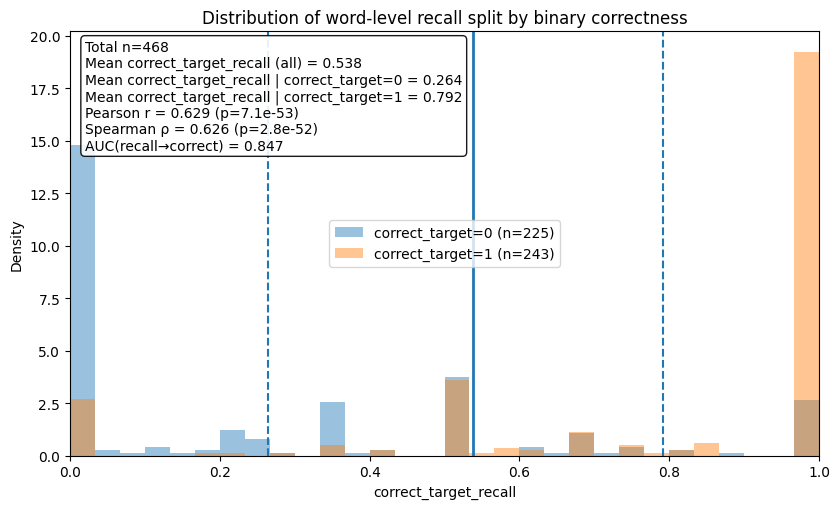

In [17]:

# Usage:
plot_recall_vs_binary(gemini_train, correct_col="correct_target", recall_col="correct_target_recall", bins=30)

In [7]:
gpt_train = pd.read_csv("./new/gpt-4o.csv")
gpt_train.shape

(468, 60)

In [18]:
gpt_train["word_recall"] = gpt_train.apply(lambda row: word_recall(row["gold_answer_tgt"], row["a_tgt"], row["target_lang"]), axis=1)
gpt_train["correct_target_recall"] = gpt_train.apply(lambda row: compute_single_recall(row["gold_answer_tgt"], row["a_tgt"], row["target_lang"]), axis=1)
gpt_train[["gold_answer_tgt", "a_tgt", "correct_target", "word_recall", "correct_target_recall"]].head(10)

,gold_answer_tgt,a_tgt,correct_target,word_recall,correct_target_recall
0,Deutschland,AFN Bremerhaven befand sich in Deutschland. AF...,True,1.000000,1.000000
1,Heckschütze,August Joseph Donatelli war während des Zweite...,False,0.000000,0.000000
2,CBC Television,"Die Dokumentarserie ""Die größte kanadische Erf...",False,1.000000,1.000000
3,2000er,Bowl-Spiele wurden ab den 2000er Jahren in die...,True,1.000000,1.000000
4,Entebbe-Krankenhaus der Stufe B,Der ursprüngliche Name des Allgemeinen Kranken...,False,0.600000,0.000000
5,Lloyd Brazil,Der Halfback der University of Detroit in der ...,True,1.000000,1.000000
6,ISIS,Die Flood Modeller-Software hieß ursprünglich ...,True,1.000000,1.000000
7,Animismus und Schamanismus,"Die Magars, eine ethnische Gruppe aus Nepal, b...",False,0.333333,0.333333
8,"Siltstein, Sandstein und Schiefer",Der unterste Teil der Espiritu-Santo-Formation...,False,0.250000,0.250000
9,1993,Die Toronto-Ausgabe der Ming Pao Daily News wu...,True,1.000000,1.000000


In [24]:
gpt_train.to_csv("./new/gpt-4o-with-recall.csv", index=False)

In [27]:
# get average of correct target values
avg_correct = gpt_train["correct_target"].mean()
print(f"Average of correct_target: {avg_correct:.4f}")

Average of correct_target: 0.6026


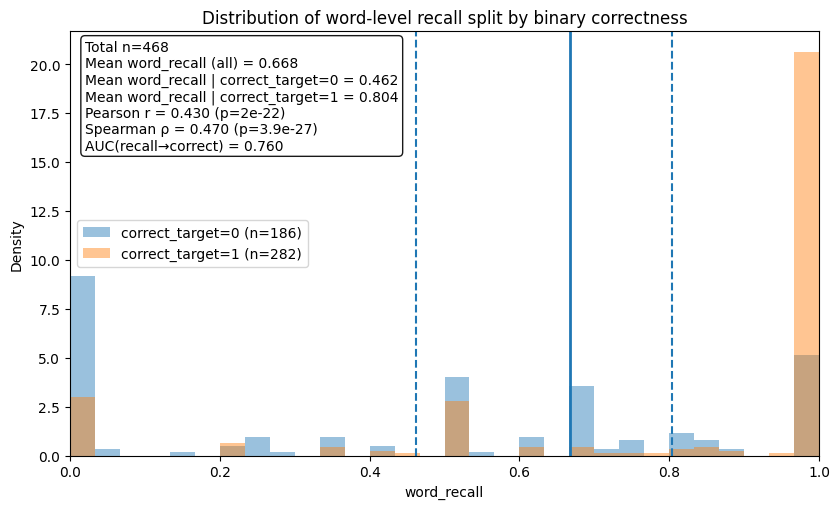

In [22]:
# Usage:
plot_recall_vs_binary(gpt_train, correct_col="correct_target", recall_col="word_recall", bins=30)

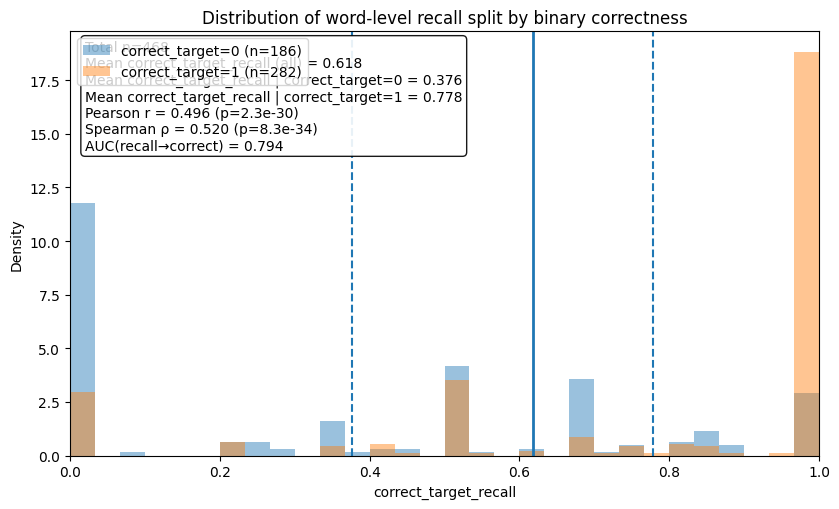

In [23]:
# Usage:
plot_recall_vs_binary(gpt_train, correct_col="correct_target", recall_col="correct_target_recall", bins=30)